# Project Name   - Telco Customer Churn

[GitHub](https://github.com/Naik-Prathamesh/Exploratory-Data-Analysis/tree/main/Telco%20Customer%20Churn)

[Dataset](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

# 1. Problem Statement

The telecommunications industry faces high customer turnover, commonly known as churn. For this company, approximately 26.5% of customers leave the service regularly. This attrition is most severe among new customers (0–5 months) and those on high-cost Fiber Optic plans. High churn increases customer acquisition costs and prevents the business from reaching its maximum Customer Lifetime Value (CLTV), as the majority of revenue is tied to long-term loyalists who stay for 70+ months.

# 2. Business Objectives

**1. Predictive Modeling:** Identify high-risk customers before they churn based on their behavior and demographics.

**2. Churn Mitigation:** Lower the current 26.5% churn rate by focusing on the "Risk Hump" (the first 6 months of service).

**3. Revenue Optimization:** Convert low-value, short-term users into long-term subscribers to increase Total Charges.

**4. Strategy Refinement:** Transition customers from manual payment methods to automated ones and from month-to-month contracts to annual commitments.

# 3. Data Understanding and Preparation


### Import Libraries

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Filter warnings

In [28]:
import warnings
warnings.filterwarnings('ignore')

### Dataset Loading

In [29]:
df = pd.read_csv("/Users/prathameshnaik/Python/EDA/Telco Customer Churn/Customer Churn.csv")

### Dataset First View

In [30]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Dataset Rows & Columns count

In [31]:
df.shape

(7043, 21)

### Dataset Information

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [33]:
# Convert TotalCharges Column to numeric

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

### Count Missing Values

In [34]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

### Count Duplicate Values

In [35]:
df.duplicated().sum()

np.int64(0)

### Variables Description

In [36]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [37]:
def convert(value):
    if value == 1:
        return "yes"
    else:
        return "no"

df['SeniorCitizen'] = df["SeniorCitizen"].apply(convert)

#converted 0 and 1 values of senior citizen to yes/no to make it easier to understand

In [39]:
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


### **What did you know about your dataset?**

The dataset consists of **7,043 customer records** with **21 columns** capturing demographic, account, and service-based attributes. It represents a snapshot of a telecommunications company’s customer base, specifically designed to analyze attrition (churn) and retention patterns. Key features include:

* **Demographic Information**: Gender, Senior Citizen status, and whether the customer has a Partner or Dependents.
* **Services Information**: Signed-up services such as Phone Service, Multiple Lines, Internet Service (DSL, Fiber optic, or None), and add-ons like Online Security, Tech Support, and Streaming TV/Movies.
* **Customer Account Information**: Tenure (months with the company), Contract type (Month-to-month, One year, Two year), Paperless Billing, and Payment Method.
* **Financial Metrics**: Monthly Charges and Total Charges.
* **Target Variable**: **Churn** (Yes/No), indicating whether the customer left within the last month.

The dataset is a rich, tabular collection containing a mix of numerical, categorical, and binary variables. It is structured for exploratory data analysis to pinpoint specific friction points—such as contract length and payment methods—that lead to customer loss, as well as to develop predictive models for proactive retention.

# 4. Exploratory Data Analysis 

## 1. Univariate Analysis

### 3.1 Churn Distribution

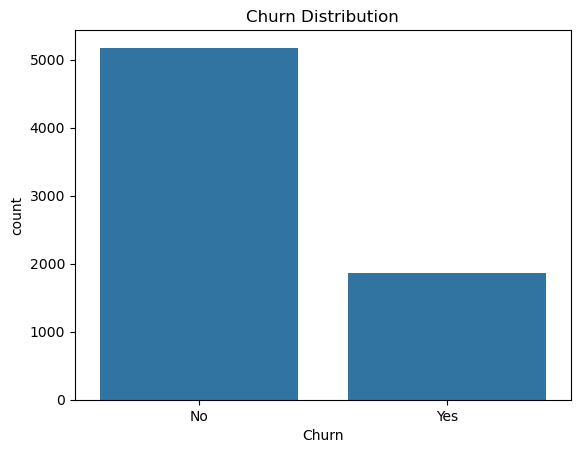

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [41]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

df['Churn'].value_counts(normalize=True) * 100

#### Insight -
**The chart shows a significant class imbalance, with roughly 26% of the customer base having churned ("Yes"), indicating a high but addressable rate of attrition.**

### 3.2 Categorical Demographics

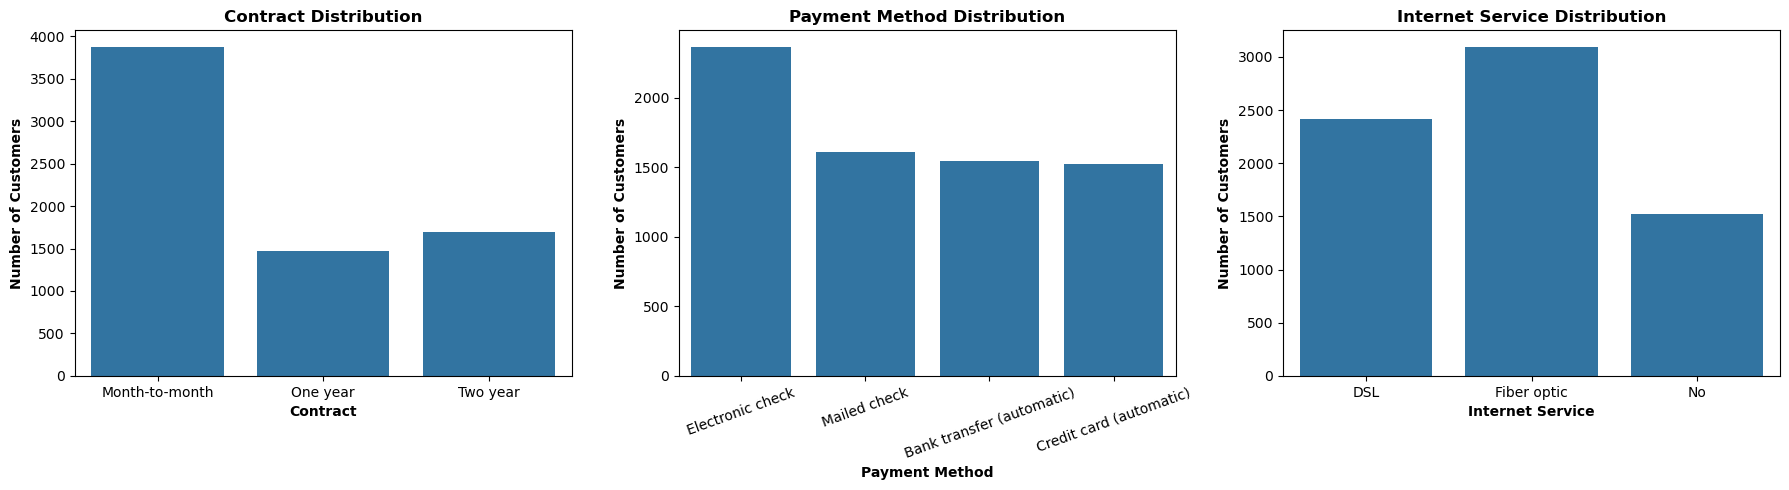

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(x='Contract', data=df, ax=axes[0])
axes[0].set_xlabel("Contract", fontweight='bold')
axes[0].set_ylabel("Number of Customers", fontweight='bold')
axes[0].set_title("Contract Distribution", fontweight='bold')

sns.countplot(x='PaymentMethod', data=df, ax=axes[1])
axes[1].set_xlabel("Payment Method", fontweight='bold')
axes[1].set_ylabel("Number of Customers", fontweight='bold')
axes[1].set_title("Payment Method Distribution", fontweight='bold')
axes[1].tick_params(axis='x', rotation=20) 

sns.countplot(x='InternetService', data=df, ax=axes[2])
axes[2].set_xlabel("Internet Service", fontweight='bold')
axes[2].set_ylabel("Number of Customers", fontweight='bold')
axes[2].set_title("Internet Service Distribution", fontweight='bold')

plt.tight_layout()
plt.show()

#### Insight -

**1. Contract Distribution: A vast majority of users prefer month-to-month flexibility over long-term commitments, which drives the high initial turnover rates observed.**

**2. Payment Method: Electronic checks are the most common payment form, suggesting a preference for manual monthly transactions over automated billing.**

**3. Internet Service: Fiber optic is the leading service choice, indicating a high-demand for high-speed data despite a significant portion of phone-only users.**

### 3.3 Numerical Distributions

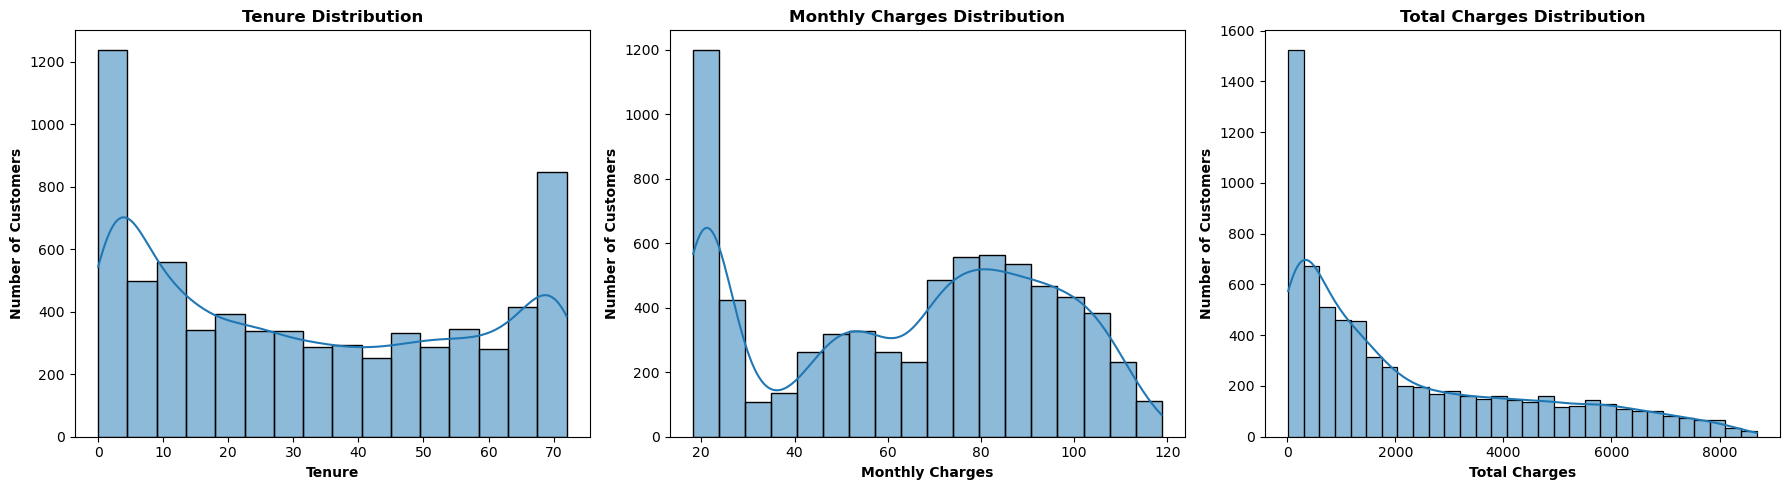

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# tenure
sns.histplot(df['tenure'], kde=True, ax=axes[0])
axes[0].set_xlabel("Tenure", fontweight='bold')
axes[0].set_ylabel("Number of Customers", fontweight='bold')
axes[0].set_title("Tenure Distribution", fontweight='bold')


# MonthlyCharges
sns.histplot(df['MonthlyCharges'], kde=True, ax=axes[1])
axes[1].set_xlabel("Monthly Charges", fontweight='bold')
axes[1].set_ylabel("Number of Customers", fontweight='bold')
axes[1].set_title("Monthly Charges Distribution", fontweight='bold')


# TotalCharges
sns.histplot(df['TotalCharges'], kde=True, bins=30, ax=axes[2])
axes[2].set_xlabel("Total Charges", fontweight='bold')
axes[2].set_ylabel("Number of Customers", fontweight='bold')
axes[2].set_title("Total Charges Distribution",  fontweight='bold')

plt.tight_layout()
plt.show()

#### Insight -

**1. Tenure Distribution: High concentrations at the 0–5 and 70+ month marks indicate a "stay or leave" trend, where customers either churn immediately or become long-term loyalists.**

**2. Monthly Charges: Most customers are split between an entry-level $20 tier and a premium $70–$100 range, with very little middle-ground pricing.**

**3. Total Charges: The data is heavily right-skewed, showing that a small group of long-tenured customers provides the majority of the total revenue.**

## 2. Bivariate Analysis

### 2.1 Categorical Factors Impacting Customer Churn

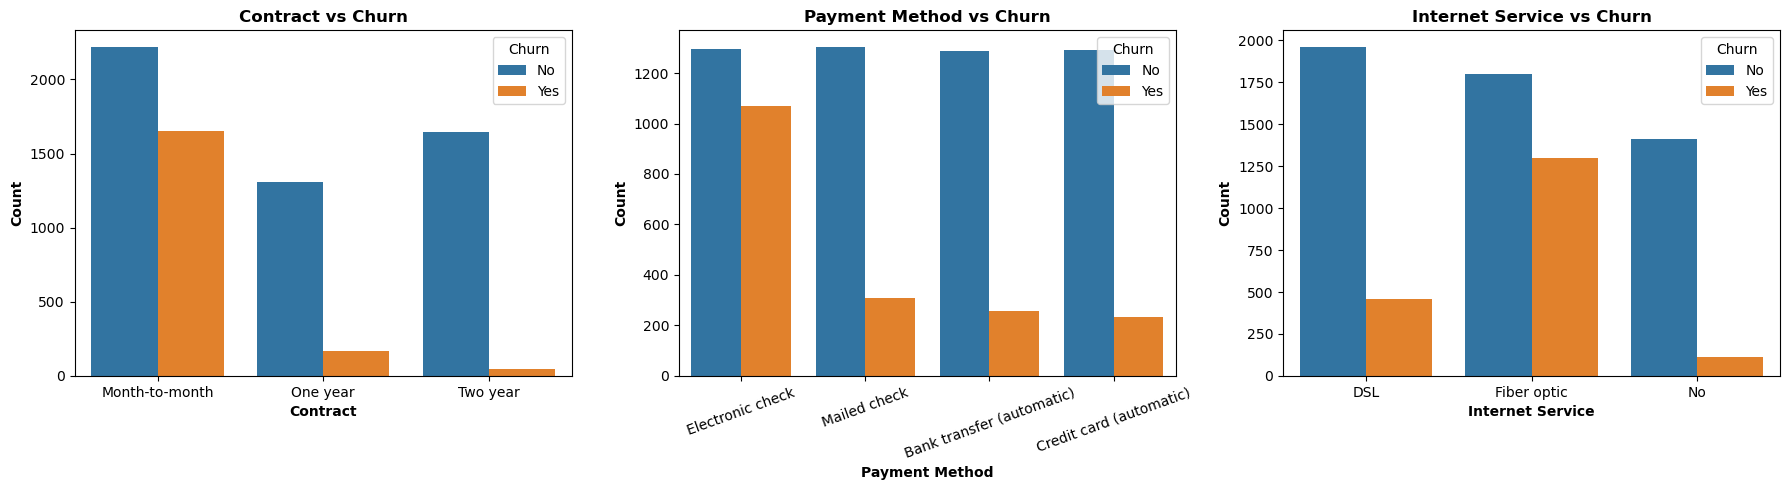

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(x='Contract', hue='Churn', data=df, ax=axes[0])
axes[0].set_xlabel("Contract", fontweight='bold')
axes[0].set_ylabel("Count", fontweight='bold')
axes[0].set_title("Contract vs Churn", fontweight='bold')


sns.countplot(x='PaymentMethod', hue='Churn', data=df, ax=axes[1])
axes[1].set_xlabel("Payment Method", fontweight='bold')
axes[1].set_ylabel("Count", fontweight='bold')
axes[1].set_title("Payment Method vs Churn", fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)

sns.countplot(x='InternetService', hue='Churn', data=df, ax=axes[2])
axes[2].set_xlabel("Internet Service", fontweight='bold')
axes[2].set_ylabel("Count", fontweight='bold')
axes[2].set_title("Internet Service vs Churn", fontweight='bold')

plt.tight_layout()
plt.show()

#### Insight -

**1. Contract vs. Churn: Customers on month-to-month contracts have a significantly higher churn rate compared to those on one- or two-year plans, highlighting contract length as the strongest predictor of retention.**

**2. Payment Method vs. Churn: Churn is disproportionately high among customers using Electronic Checks, while those with automated payment methods (Bank Transfer or Credit Card) show much higher loyalty.**

**3. Internet Service vs. Churn: Fiber Optic users exhibit the highest churn volume; despite being a premium service, it appears to have a lower retention rate than DSL or customers with no internet service.**

### 2.2 Churn Distribution by Senior Citizen Status

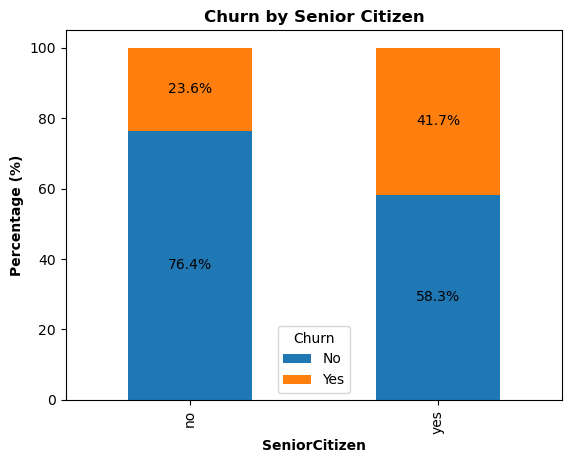

In [53]:
total_counts = df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True).unstack() * 100

ax = total_counts.plot(kind='bar', stacked=True, color=['#1f77b4', '#ff7f0e'])

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        x = p.get_x() + p.get_width() / 2
        y = p.get_y() + height / 2
        ax.text(x, y, f'{height:.1f}%', ha='center', va='center')

ax.set_title('Churn by Senior Citizen', fontweight='bold')
ax.set_xlabel('SeniorCitizen', fontweight='bold')
ax.set_ylabel('Percentage (%)', fontweight='bold')

plt.show()

#### Insight -

**Churn by Senior Citizen: Senior citizens have a much higher churn rate (41.7%) compared to non-senior citizens (23.6%), suggesting that this demographic may face specific barriers such as price sensitivity or technical difficulties.**

## 3. Multivariate Analysis

### 3.1 Customer Churn Patterns Across Tenure, Charges, and Services

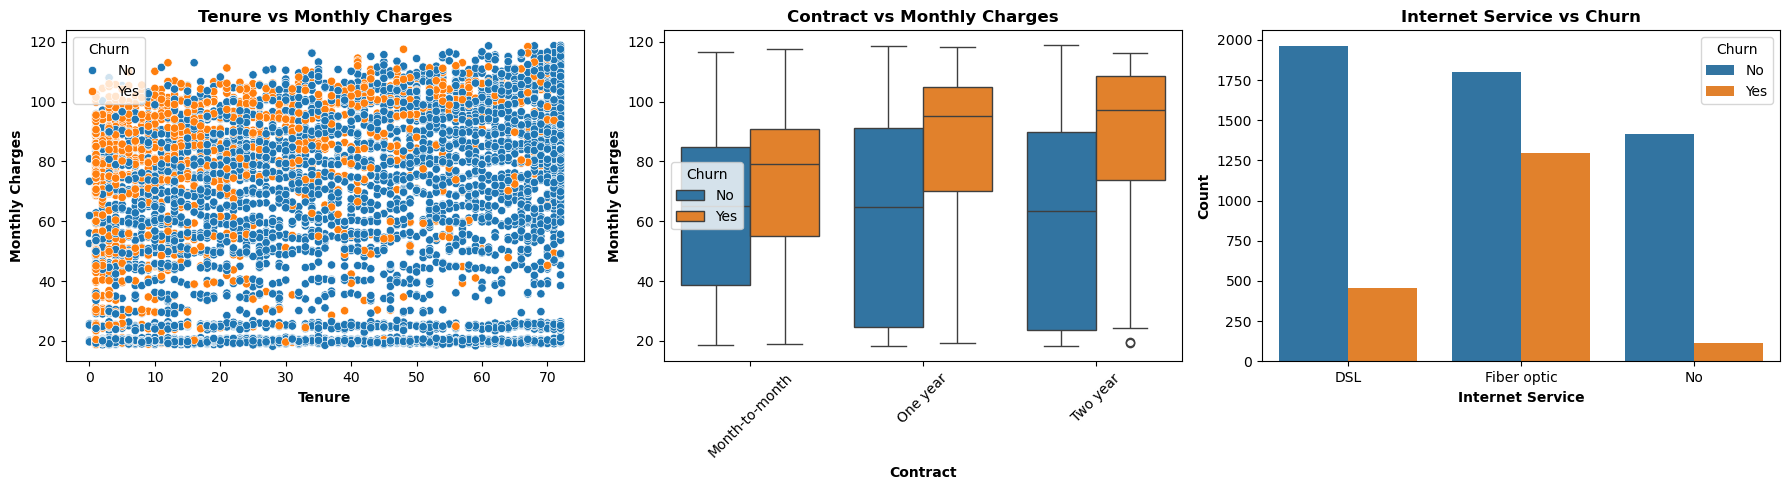

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter: tenure vs MonthlyCharges
sns.scatterplot(x='tenure', y='MonthlyCharges', hue='Churn', data=df, ax=axes[0])
axes[0].set_title("Tenure vs Monthly Charges", fontweight='bold')
axes[0].set_xlabel("Tenure", fontweight='bold')
axes[0].set_ylabel("Monthly Charges", fontweight='bold')

# Boxplot: Contract vs MonthlyCharges
sns.boxplot(x='Contract', y='MonthlyCharges', hue='Churn', data=df, ax=axes[1])
axes[1].set_title("Contract vs Monthly Charges", fontweight='bold')
axes[1].set_xlabel("Contract", fontweight='bold')
axes[1].set_ylabel("Monthly Charges", fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

# Countplot: InternetService vs Churn
sns.countplot(x='InternetService', hue='Churn', data=df, ax=axes[2])
axes[2].set_title("Internet Service vs Churn", fontweight='bold')
axes[2].set_xlabel("Internet Service", fontweight='bold')
axes[2].set_ylabel("Count", fontweight='bold')

plt.tight_layout()
plt.show()

#### Insight -

**High monthly costs are the most aggressive driver of churn for new customers, particularly within the Fiber Optic segment. This suggests that price-sensitive new users are the most vulnerable group, necessitating targeted discounts or loyalty rewards in their first year.**

### 3.2 Correlation Analysis of Tenure, Monthly Charges, and Total Charges

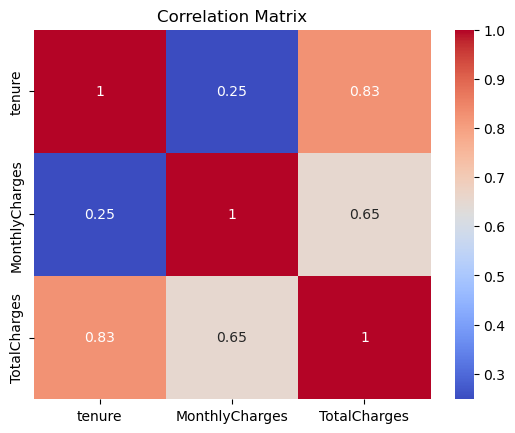

In [55]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

#### Insight -

**1. Correlation Matrix: There is a very strong positive correlation (0.83) between Tenure and TotalCharges, confirming that long-term customer retention is the primary driver of high lifetime revenue.**

**2. Monthly vs. Total: A moderate correlation (0.65) between MonthlyCharges and TotalCharges shows that while higher rates increase revenue, they aren't as influential as simply keeping a customer for a longer duration.**

# 5. Business Recommendations

**1. Onboarding Retention Program:** Implement a loyalty discount or "bonus service" for customers who hit the 6-month and 12-month milestones to move them past the high-risk early phase.

**2. Contractual Incentives:** Provide a 10-15% discount for customers who switch from Month-to-month to One-year contracts, as annual contracts show significantly lower churn rates.

**3. Digital Transformation:** Launch a campaign to move users from Electronic Checks to Credit Card (Automatic) payments. Automated billing removes the monthly "friction point" where a customer decides whether to stay or go.

**4. Service-Specific Support:** Investigate Fiber Optic service issues. Since Fiber Optic has the highest churn volume despite being a premium product, the company should conduct a quality-of-service audit or offer proactive tech support to these high-paying users.

# 6. Conclusion
The analysis confirms that Tenure is the single greatest driver of total revenue. The company’s primary weakness is its Month-to-month contract structure combined with Manual Payment methods, which creates a low barrier for exit. By stabilizing the onboarding experience and incentivizing long-term commitment, the company can significantly reduce churn, protect its high-value Fiber Optic revenue, and build a more predictable, long-term profit model.